In [1]:
import os
import csv
import pandas as pd
import numpy as np
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
from Helper.Load_Anndata import read_and_filter_h5ad
from Helper.Process_Anndata import AnnObject
import Helper.train_and_plot as tp
import Helper.utils as hutil
import math
from collections import Counter
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# adata1 = sc.read_h5ad("../Mouse Tabula Muris/tabula-muris-senis-facs-processed-official-annotations-Brain_Myeloid.h5ad")
# adata2 = sc.read_h5ad("../Mouse Tabula Muris/tabula-muris-senis-facs-processed-official-annotations-Brain_Non-Myeloid.h5ad")
# adata = adata1.concatenate(adata2)

In [4]:
# adata.write_h5ad("../Mouse Tabula Muris/tabula-muris-senis-facs-processed-official-annotations-Brain_combined.h5ad", compression='gzip')

In [5]:
raw_adata = read_and_filter_h5ad("../Mouse_Tabula_Muris/tabula-muris-senis-facs-processed-official-annotations-Brain_combined.h5ad", 
                             "cell_ontology_class", "age")

Checking low count cell types...
macrophage  has too low counts
interneuron  has too low counts
neuron  has too low counts
brain pericyte  has too low counts
Bergmann glial cell  has too low counts
neuroepithelial cell  has too low counts
T cell  has too low counts
mature NK T cell  has too low counts
CD8-positive, alpha-beta T cell  has too low counts
ependymal cell  has too low counts
oligodendrocyte precursor cell  has too low counts
neuronal stem cell  has too low counts
medium spiny neuron  has too low counts
Checking skewed count cell types...
astrocyte  has skewed cell counts


In [6]:
organ = "Brain"
processed_folder = "../2024_Nov/Processed_data/"

In [7]:
font_size_config = {
    'axes.titlesize': 16,  # Title font size
    'axes.labelsize': 14,  # Axes labels (x and y) font size
    'xtick.labelsize': 12,  # X-axis tick label font size
    'ytick.labelsize': 12,  # Y-axis tick label font size
}

## Preprocess Anndata

In [8]:
adataObject = AnnObject(raw_adata, "cell_ontology_class", "age", "m")

logarithmizing the adata into processed_object


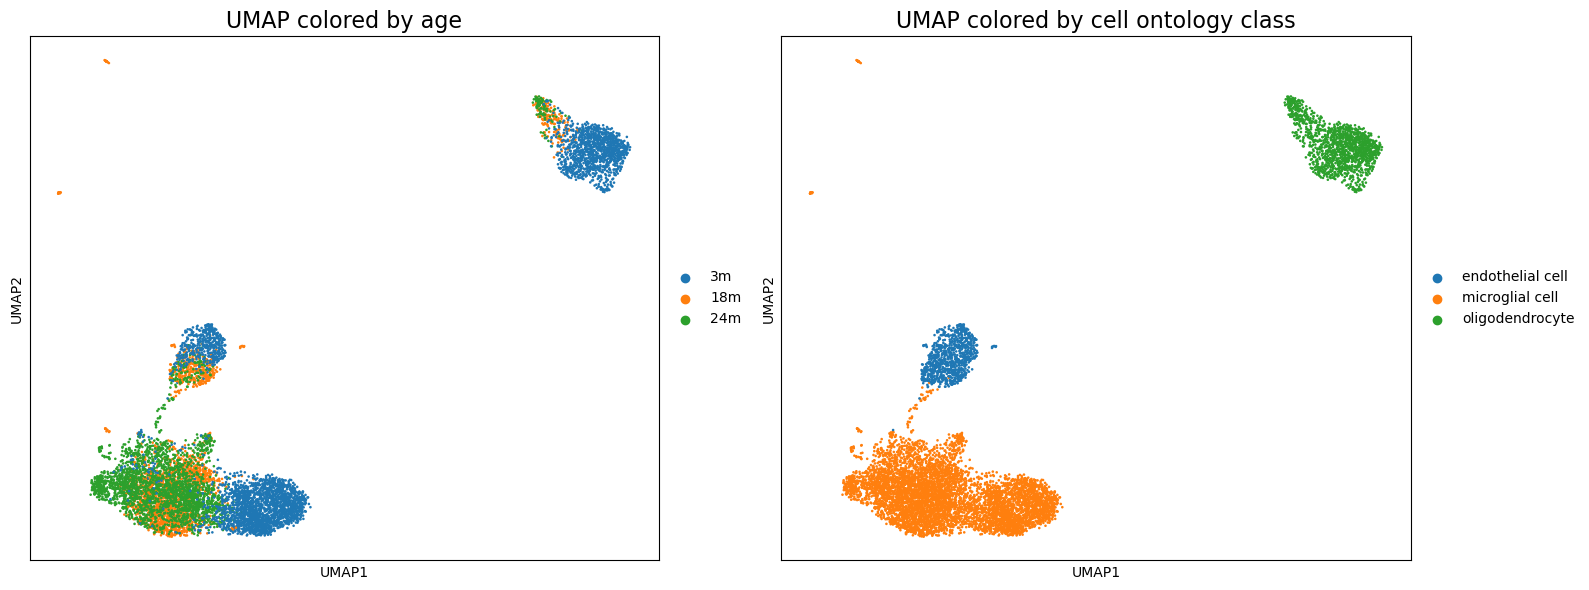

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

with plt.rc_context(font_size_config):
    sc.pl.umap(adataObject.processed_adata, color="age", ax=axs[0], show=False, title='UMAP colored by age')

    sc.pl.umap(adataObject.processed_adata, color="cell_ontology_class", ax=axs[1], show=False, title='UMAP colored by cell ontology class')

plt.tight_layout()
plt.show()

In [10]:
selected_gene_by_frac = hutil.filter_low_genes(adataObject.raw_counts, adataObject.celltype_dict)

100%|███████████████████████████████████████████████| 3/3 [00:01<00:00,  2.72it/s]


In [11]:
correlated_index = hutil.get_correlated_genes(adataObject, organ, selected_gene_by_frac)

Correlation output directory already exists.
Deleting previous correlated_info files...
Processing cell type microglial cell...
Processing cell type endothelial cell...
Processing cell type oligodendrocyte...


## Compute the frequencies

In [12]:
metaCells, metaAges = hutil.get_metaCells(adataObject.celltype_dict, adataObject.raw_counts, adataObject.age_dict)

In [13]:
pred_freq_matrices, freq_age_group = hutil.get_gene_frequencies(metaCells, metaAges, adataObject.raw_counts.index, 
                                                                selected_gene_by_frac)

processing celltype:  microglial cell
processing celltype:  endothelial cell
processing celltype:  oligodendrocyte


## Run model and generate results
r: Expected frequency from the linear model
k: counts of this specific gene
t: sum of the counts across all genes for that cell

In [14]:
def initialize_output_file(organ, r_squareds_dir="./r_squareds"):
    os.makedirs(r_squareds_dir, exist_ok=True)
    file_path = os.path.join(r_squareds_dir, f"{organ}_r_squared_summary.csv")
    print(file_path)
    if os.path.isfile(file_path):
        print("Deleting previous r_squared file")
        os.remove(file_path)
    return file_path

In [15]:
num_features = []
pred_age_plot = {}
file_path = f"./R_Squareds/{organ}_r_squared_summary.csv"
initialize_output_file(organ)

# Dictionary to store r_squared values for each cell type and gene count
r_squared_results = {}

./r_squareds/Brain_r_squared_summary.csv
Deleting previous r_squared file


Processing cell type: microglial cell


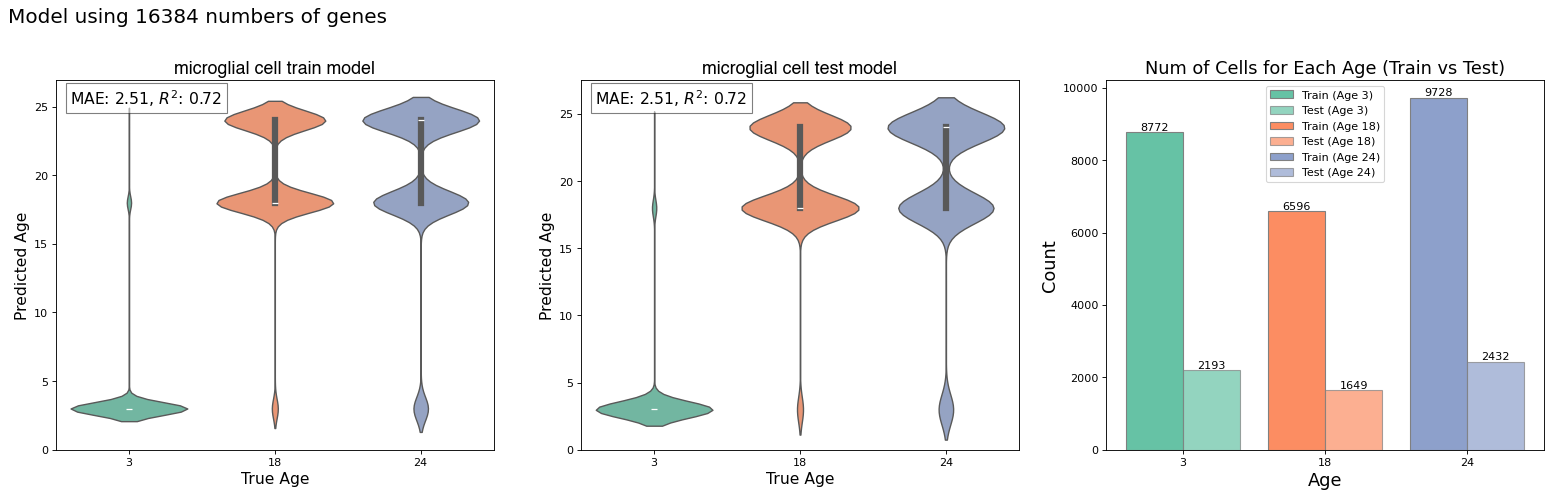

Processing cell type: endothelial cell


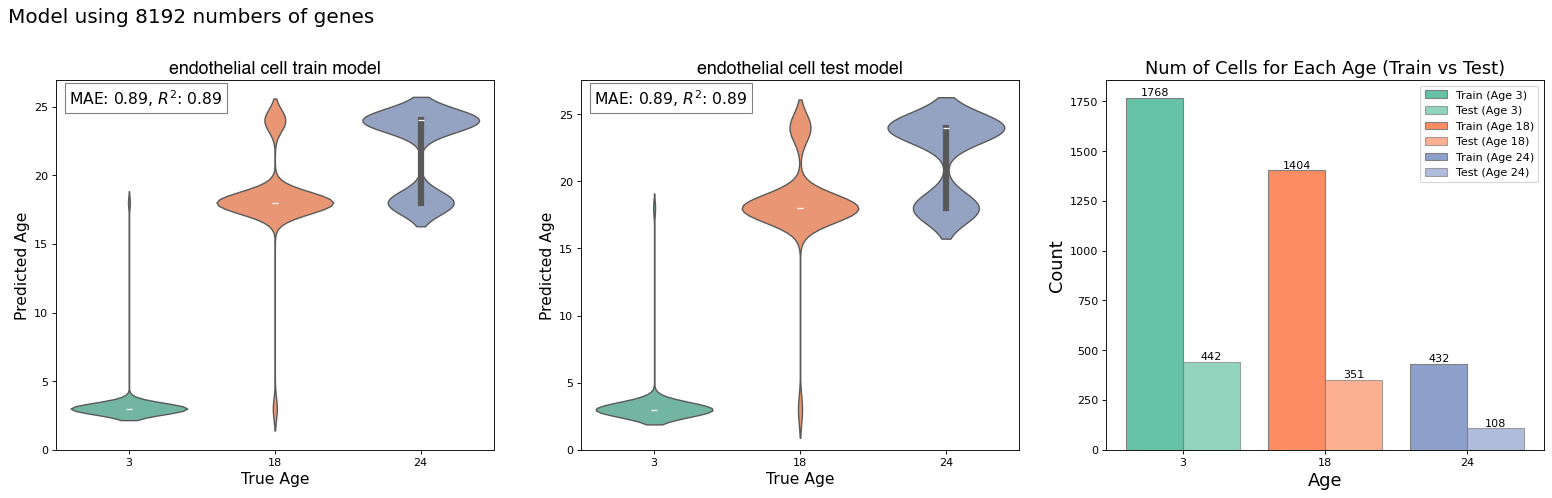

Processing cell type: oligodendrocyte


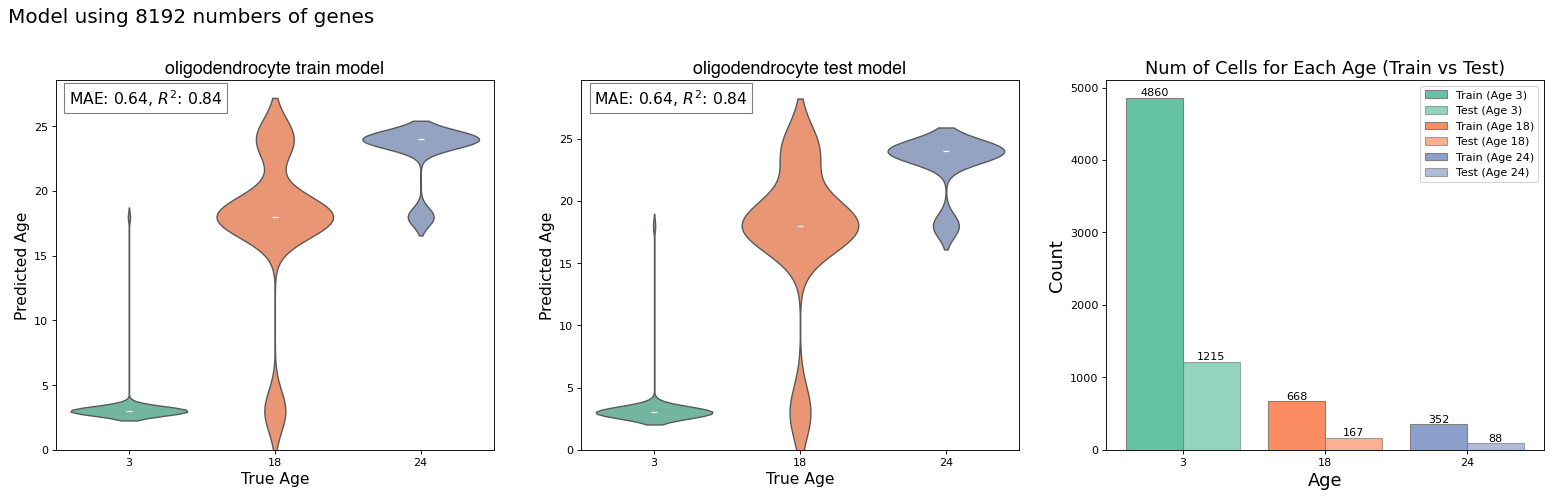

In [16]:
# Iterate over each cell type in the predicted frequency matrices
for celltype in adataObject.celltype_dict:
    print(f"Processing cell type: {celltype}")
    
    cell_group = adataObject.celltype_dict[celltype]
    raw_cells = np.array(adataObject.raw_counts[cell_group])
    
    ages = np.array([adataObject.age_dict[cell] for cell in cell_group])
    donor_ids = np.array([adataObject.processed_adata.obs.loc[cell, "mouse.id"] for cell in cell_group])
    unique_donors = np.unique(donor_ids)
    donor_kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Select the correlated genes for the current cell type
    correlated_index_list = correlated_index[celltype]

    # Store cross-entropy results for different gene counts
    celltype_r_squared = {}
    
    def try_model_across_fold():
        train_r2s = []
        for fold_idx, (train_idx, _) in enumerate(donor_kf.split(unique_donors)):
            train_donors = unique_donors[train_idx]
            # Masks for cell-level selection
            train_mask = np.isin(donor_ids, train_donors)
            # Get raw counts and ages per fold
            X_train = raw_cells[:, train_mask].T[:, selected_index]
            y_train = ages[train_mask]

            # Run the poisson function
            train_predicted_ages = tp._run_poisson(
                pred_freqs, X_train, y_train, freq_age_group[celltype]
            )
            r2 = (pearsonr(y_train, train_predicted_ages)[0]) ** 2
            train_r2s.append(r2)
        return train_r2s
    
    i = 0
    while (2**i) <= len(correlated_index_list):
        gene_count = 2**i
        i += 1
        selected_index = correlated_index_list[:gene_count]
        # Retrieve the predicted frequency matrix for the current cell type
        pred_freqs = pred_freq_matrices[celltype][selected_index, :]
        train_r2s = try_model_across_fold()
        r2 = sum(train_r2s) / 5
        celltype_r_squared[gene_count] = r2
    
    r_squared_results[celltype] = {num_genes: (r_squareds if not np.isnan(r_squareds).any() else 0) for num_genes, r_squareds in celltype_r_squared.items()}
    optimal_gene_counts = max(r_squared_results[celltype], key=r_squared_results[celltype].get)
    num_features.append({"celltype": celltype, "num_features": optimal_gene_counts})
    
    optimal_index = correlated_index_list[:optimal_gene_counts]
    optimal_pred_freqs = pred_freq_matrices[celltype][optimal_index, :]
    
    train_ages, store_train_predict, test_ages, store_test_predict, full_predicted_ages = tp.test_model_across_fold(donor_kf, donor_ids, unique_donors, raw_cells, ages, optimal_index, optimal_pred_freqs, freq_age_group[celltype])
    
    # save the predicted ages to anndata for plotting later
    adataObject.processed_adata.obs.loc[cell_group, "pred_age"] = full_predicted_ages

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6), dpi=80)
    tp._plot_violin(file_path = file_path, ax = ax1, x = train_ages, y = store_train_predict, name = celltype, record = False)
    tp._plot_violin(file_path = file_path, ax = ax2, x = test_ages, y = store_test_predict, name = celltype)
    tp._plot_cell_count(ax3, dict(sorted(Counter(train_ages).items())), dict(sorted(Counter(test_ages).items())))
    fig.text(0.1, 1, f"Model using {optimal_gene_counts} numbers of genes", fontsize = 18)
    fig.savefig(f"./Model_Figures/{organ}_{celltype}_model.png", bbox_inches='tight', dpi = 300)
    plt.show()
tp.write_feature_summary(organ, num_features)

## Save predicted age

In [17]:
adataObject.processed_adata.obs["pred_age"] = [str(int(x)) + "m" for x in adataObject.processed_adata.obs["pred_age"]]

## Save processed adata

In [18]:
adataObject.processed_adata.write_h5ad(filename = f"{processed_folder}{organ}_Processed_Data.h5ad", compression='gzip')